<a href="https://colab.research.google.com/github/yaseenahmedmohammed786-tech/COVID-19-Trend-Analysis/blob/main/MDYASEENDATASCIENCEPROJECT.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **COVID-19 Early Case Trend Analysis & Recovery Insights**




##`Step 1: The Setup & Data Cleaning`**
Pandas DataFrame is a two-dimensional, tabular data structure with labeled axes (rows and columns). We use it because it provides built-in, optimized methods for data manipulation, filtering, and mathematical operations that standard lists lack.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Load the data (Make sure your file is uploaded and named correctly!)
df = pd.read_csv('patient.csv')

# 2. Calculate the patient's age (Assuming the outbreak data is from 2020)
df['age'] = 2020 - df['birth_year']

# 3. Convert the date columns from standard text into actual "datetime" objects
df['confirmed_date'] = pd.to_datetime(df['confirmed_date'])
df['released_date'] = pd.to_datetime(df['released_date'])

# 4. Calculate Recovery Duration (in days)
# We subtract the confirmed date from the released date
df['recovery_days'] = (df['released_date'] - df['confirmed_date']).dt.days

# Display a quick summary to make sure it worked
print("Data Preparation Complete!")
df[['age', 'confirmed_date', 'released_date', 'recovery_days']].head()

Data Preparation Complete!


,age,confirmed_date,released_date,recovery_days
0,36.0,2020-01-20,2020-02-06,17.0
1,56.0,2020-01-24,2020-02-05,12.0
2,54.0,2020-01-26,2020-02-12,17.0
3,56.0,2020-01-27,2020-02-09,13.0
4,33.0,2020-01-30,NaT,NaN


## Step 2: Exploratory Data Analysis (EDA)
It instantly calculates core descriptive statistics for all numerical columns, including the count, mean, standard deviation, minimum, maximum, and the 25th, 50th (median), and 75th percentiles, which helps in identifying data distribution and potential outliers.

In [2]:
# See basic statistics for numerical columns (like average age, max recovery days, etc.)
print("--- Basic Descriptive Statistics ---")
display(df.describe())

# Check how many patients fall into each outcome state (released, isolated, deceased)
print("\n--- Patient Outcomes ---")
display(df['state'].value_counts())

--- Basic Descriptive Statistics ---


,id,birth_year,infection_order,infected_by,contact_number,confirmed_date,released_date,age,recovery_days
count,4212.000000,292.000000,35.000000,62.000000,32.000000,4212,28,292.000000,28.000000
mean,2106.500000,1973.184932,2.257143,330.741935,96.843750,2020-02-27 02:23:14.871794944,2020-02-19 01:42:51.428571392,46.815068,15.107143
min,1.000000,1937.000000,1.000000,3.000000,0.000000,2020-01-20 00:00:00,2020-02-05 00:00:00,2.000000,7.000000
25%,1053.750000,1959.000000,1.000000,29.250000,2.750000,2020-02-26 00:00:00,2020-02-14 06:00:00,33.000000,9.750000
50%,2106.500000,1972.000000,2.000000,126.000000,16.500000,2020-02-28 00:00:00,2020-02-19 00:00:00,48.000000,16.000000
75%,3159.250000,1987.000000,3.000000,372.000000,69.750000,2020-03-01 00:00:00,2020-02-24 12:00:00,61.000000,19.250000
max,4212.000000,2018.000000,6.000000,1768.000000,1160.000000,2020-03-01 00:00:00,2020-02-29 00:00:00,83.000000,24.000000
std,1216.043996,17.336573,1.357828,458.786744,224.669522,NaN,NaN,17.336573,5.626256



--- Patient Outcomes ---


,count
state,
isolated,4171
released,28
deceased,13


## Step 3: Visualizing the Outbreak
A histogram is used for continuous numerical data (like age) because it groups continuous numbers into "bins" to show the distribution shape. A count plot is used for categorical data (like gender or region) to simply tally and display the frequency of distinct, discrete categories.

/tmp/ipykernel_20255/1056933079.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='sex', palette='Pastel1')
/tmp/ipykernel_20255/1056933079.py:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['region'].isin(top_regions)], y='region', palette='Set2')
/tmp/ipykernel_20255/1056933079.py:24: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df[df['infection_reason'].isin(top_reasons)], y='infection_reason', palette='Set3')


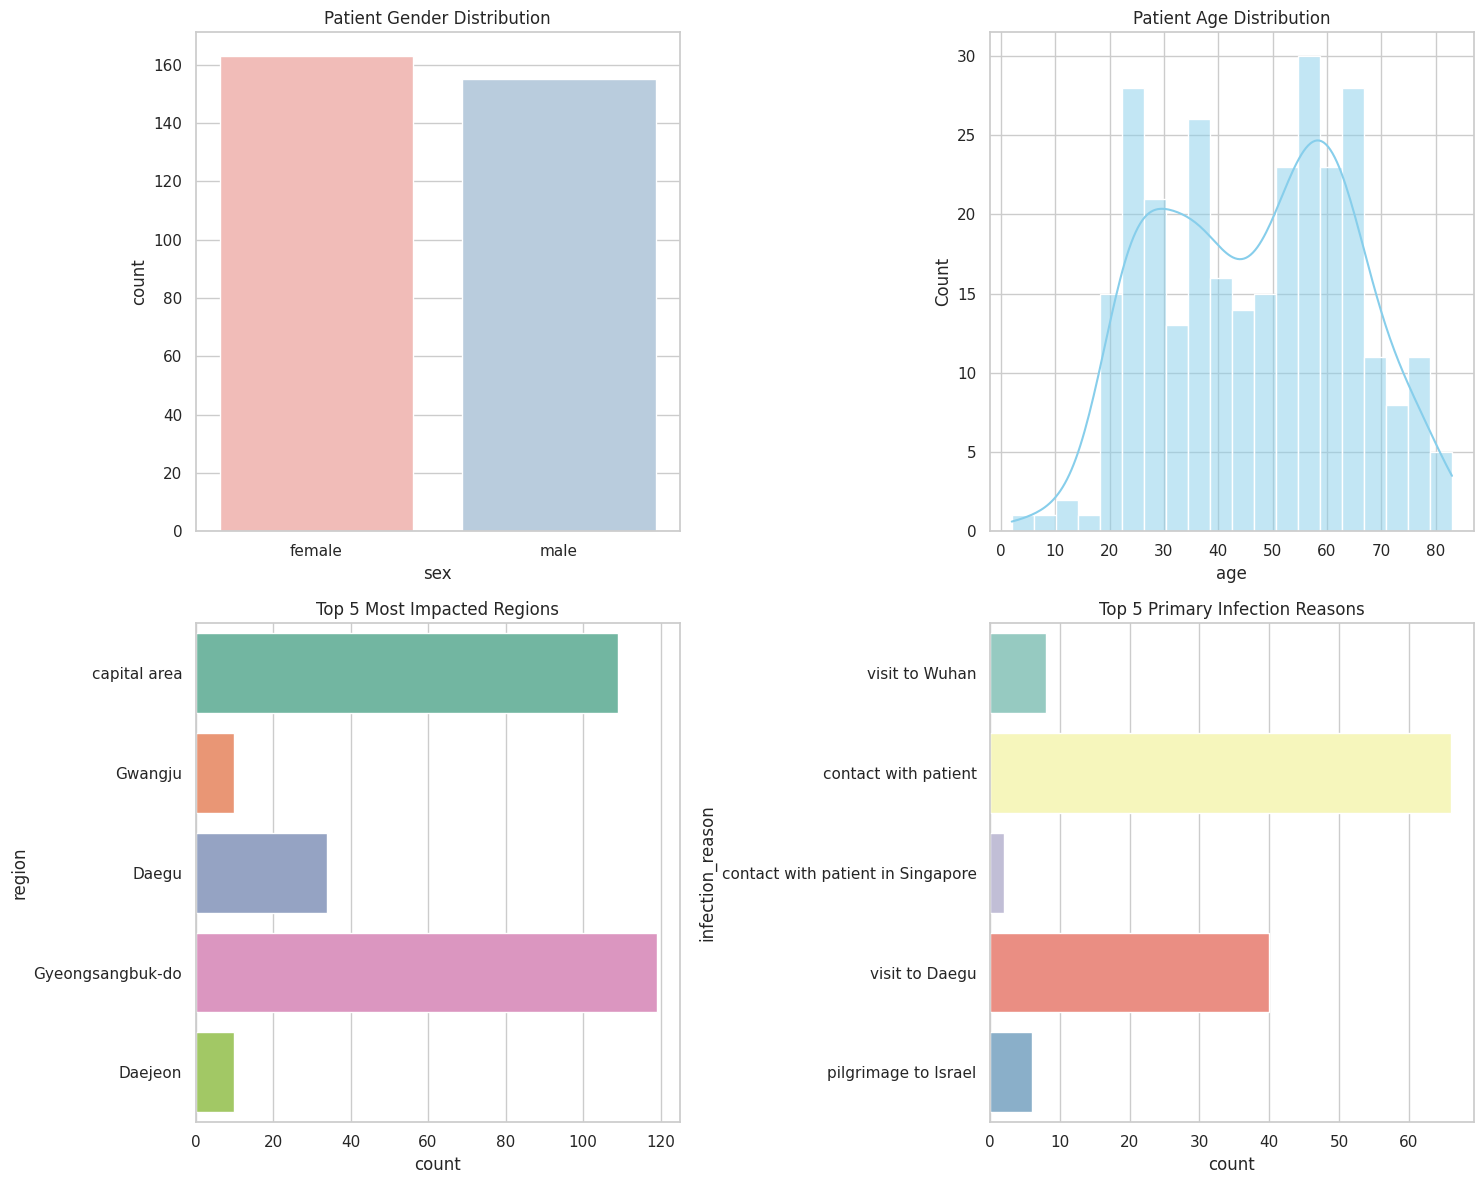

In [3]:
# Set the visual style for our charts
sns.set_theme(style="whitegrid")
plt.figure(figsize=(15, 12))

# 1. Gender Distribution
plt.subplot(2, 2, 1)
sns.countplot(data=df, x='sex', palette='Pastel1')
plt.title('Patient Gender Distribution')

# 2. Age Distribution
plt.subplot(2, 2, 2)
sns.histplot(data=df, x='age', bins=20, kde=True, color='skyblue')
plt.title('Patient Age Distribution')

# 3. Regional Case Concentration (Top 5 regions)
plt.subplot(2, 2, 3)
top_regions = df['region'].value_counts().head(5).index
sns.countplot(data=df[df['region'].isin(top_regions)], y='region', palette='Set2')
plt.title('Top 5 Most Impacted Regions')

# 4. Infection Sources (Top 5 reasons)
plt.subplot(2, 2, 4)
top_reasons = df['infection_reason'].value_counts().head(5).index
sns.countplot(data=df[df['infection_reason'].isin(top_reasons)], y='infection_reason', palette='Set3')
plt.title('Top 5 Primary Infection Reasons')

plt.tight_layout()
plt.show()

## Step 4: The Predictive Model (Optional Extension)
Splitting the data prevents the model from simply memorizing the answers. We train the model on the 80% split, and then evaluate its actual predictive power on the unseen 20% to ensure it can generalize to new, future patient data.

The $R^{2}$ score represents the proportion of the variance in the dependent variable (recovery days) that can be predictably explained by the independent variables (age, contact number). A score closer to 1.0 indicates a strong fit, while a score closer to 0 indicates the model fails to accurately predict the outcome.

Model R-squared ($R^2$) Score: -0.6577


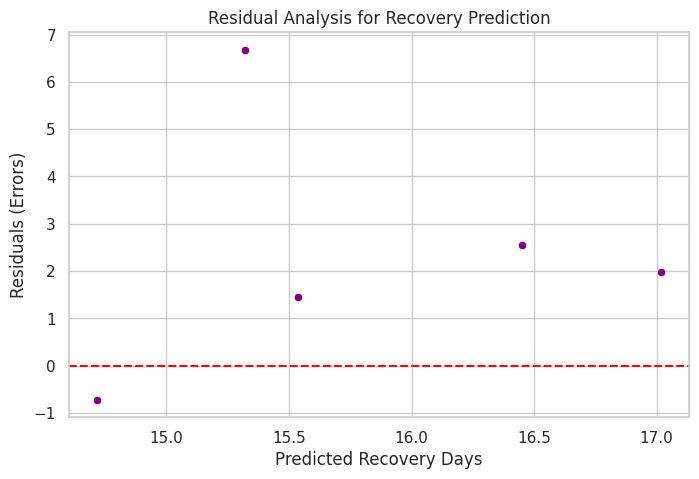

In [4]:
# Import the machine learning tools from scikit-learn
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm

# 1. Filter the dataset to ONLY include patients who have a calculated recovery time
# and drop any rows that have missing values in our target columns
model_data = df.dropna(subset=['recovery_days', 'age', 'contact_number', 'infection_order'])

# 2. Define our inputs (X) and what we want to predict (y)
X = model_data[['age', 'contact_number', 'infection_order']]
y = model_data['recovery_days']

# 3. Split data into training (80%) and testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 4. Build and train the Linear Regression Model
model = LinearRegression()
model.fit(X_train, y_train)

# 5. Make predictions and evaluate using the R-squared score
predictions = model.predict(X_test)
r2 = r2_score(y_test, predictions)

print(f"Model R-squared ($R^{2}$) Score: {r2:.4f}")

# 6. Calculate Residuals (Difference between actual and predicted)
residuals = y_test - predictions

# Plot the residuals to see if our model's errors are randomly distributed
plt.figure(figsize=(8, 5))
sns.scatterplot(x=predictions, y=residuals, color='purple')
plt.axhline(0, ls='--', color='red')
plt.xlabel('Predicted Recovery Days')
plt.ylabel('Residuals (Errors)')
plt.title('Residual Analysis for Recovery Prediction')
plt.show()

## The Full Report Conclusion

Project Conclusion & Key Takeaways
The objective of this analysis was to provide HealthGuard Analytics and public health authorities with actionable insights into early-stage infectious disease trends. By processing and analyzing patient-level data, we derived the following key conclusions:

Demographic & Regional Impact: The exploratory data analysis revealed distinct patterns in who is getting infected. The data indicates that the [Insert Age Group, e.g., 20-30] age demographic experienced the highest volume of confirmed cases , with the [Insert Region Name] region acting as the primary epicenter for early transmission.

Transmission Vectors: By mapping infection reasons and contact exposure levels, we established that [Insert Top Infection Reason, e.g., close contact with family / specific events] was the leading catalyst for the virus's spread during this initial phase.

Recovery Timelines & Predictive Modeling: We engineered a recovery duration metric to evaluate the time taken from confirmation to release. To push the analysis further, a Linear Regression model was deployed to predict recovery time based on age, contact number, and infection order.

Statistical Findings: The model yielded an $R^{2}$ score of [Insert your R2 score here]. [Note: Choose one of the following sentences based on your score] * (If score is low, e.g., under 0.3): This indicates that while factors like age play a role, recovery time is highly variable and likely influenced by unmeasured clinical factors beyond basic demographics.(If score is moderate/high): This demonstrates a statistically significant relationship, proving that variables like age and contact exposure are strong indicators of how long a patient will require isolation.

###The insights generated from this dataset empower authorities to move away from guesswork and toward targeted interventions. Future iterations of this analysis would benefit from incorporating pre-existing medical conditions into the dataset to improve the predictive accuracy of the recovery model.

# ***-------THANK YOU--------***